# Noise-prior shape — normal vs uniform, head-to-head

Two sweeps whose **base** config differs in the noise-prior shape (`sweep.yaml` run with
`action_prior`/`state_prior` = normal, and again = uniform), each 72 configs × 40 curated
inits. Both objectives (`peak` / `last`) are on every row.

**Read the design before the results.** These are *not* two runs identical but for the prior:

* Each run is an **OFAT star centred on a different base**, and both sweep `action_prior`
  *and* `state_prior` as OFAT factors of their own. The prior shape is therefore a **column**
  on every row, in both runs — which is what the contrast is built on here. The `run` label
  is provenance (which base the star was centred on), not the treatment.
* `config_id` is **not** comparable across runs. `build_configs` drops a grid value that
  equals base, so id 14 is `ofat.action_prior=uniform` in one run and `ofat.action_prior=normal`
  in the other. Merging on it silently inverts the contrast — §5 pairs on the knob values instead.
* The two bases differ in **both** priors at once, so "run" confounds them; only the
  per-column contrast separates them.

§6 measures the run-to-run reproducibility floor, which bounds how large an effect any of
this can resolve. Read it before believing §1–§5.

## Setup — load both runs, pool, tag by provenance

In [35]:
from dreamerv4uwm.planning.experiments.study.analysis import dataset, charts, schema
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
pd.set_option("display.width", 180)

def load_run(run, rebuild=False):
    """Cached loader: <run>/analysis/trees.parquet if present, else build from the shards
    and write the cache (same helper as explore_results.ipynb)."""
    pq = Path(run) / "analysis" / "trees.parquet"
    return dataset.load(pq) if (pq.exists() and not rebuild) else dataset.build(run, out=pq)

RUNS = {"normal": "mcts_sweep/run_normal", "uniform": "mcts_sweep/run_uniform"}
dfs  = {k: load_run(v).assign(run=k) for k, v in RUNS.items()}
df   = pd.concat(dfs.values(), ignore_index=True)
print({k: len(v) for k, v in dfs.items()}, "-> pooled", len(df), "rows")

{'normal': 2880, 'uniform': 2880} -> pooled 5760 rows


In [36]:
# --- objective switch (same convention as explore_results.ipynb) --------------
OBJ   = "last"                        # "peak" | "last"
GAIN  = f"g_random_{OBJ}"             # vs ONE undirected rollout
GAIN2 = f"g_greedy_{OBJ}"             # vs best-of-N shooting
ABS   = f"tree_{OBJ}"                 # absolute reward achieved
OUT   = GAIN

PRIOR = "action_prior"                # the contrast: "action_prior" | "state_prior"
COL   = {"normal": "#4c78a8", "uniform": "#e45756"}
OUTS  = [c for c in ["g_random_peak", "g_greedy_peak", "tree_peak",
                     "g_random_last", "g_greedy_last", "tree_last"] if c in df.columns]

# knobs to compare across prior levels — exclude BOTH priors (one is the contrast, the
# other is confounded with it through the two bases)
KNOBS = [k for k in schema.FACTORS if k in df.columns and df[k].nunique(dropna=True) > 1
         and k not in ("action_prior", "state_prior")]
print(f"objective={OBJ} -> {GAIN} / {GAIN2} / {ABS}   contrast={PRIOR}")
print("knobs compared:", KNOBS)

objective=last -> g_random_last / g_greedy_last / tree_last   contrast=action_prior
knobs compared: ['ctx_noise', 'horizon', 'sim_horizon', 'branching', 'action_temp', 'c_ucb', 'max_depth', 'n_iterations']


### 0. The design, made explicit

Both priors vary inside *both* runs, so the pooled data has all four combinations — just not
in equal numbers (each run over-samples its own base). That imbalance is why §1 is a
*marginal* read and §5 is the controlled one.

In [37]:
print("rows per (run, action_prior, state_prior):")
print(df.groupby(["run", "action_prior", "state_prior"], observed=True).size().to_string())

# how much do the two runs actually overlap? (identical settings of every knob)
KN = [k for k in schema.FACTORS if k in df.columns]
kn, ku = [set(map(tuple, d[KN].drop_duplicates().to_numpy())) for d in dfs.values()]
print(f"\ndistinct knob-tuples: normal={len(kn)}  uniform={len(ku)}  shared={len(kn & ku)}")
print("(the shared ones are the Tier-2 `rand.*` configs, which are drawn from the same seed")
print(" in both runs and so do not depend on the base — plus the swapped prior-OFAT arms)")

# config_id is NOT a valid join key across runs — show it rather than assert it
tn = dfs["normal"].groupby("config_id").config_tag.first()
tu = dfs["uniform"].groupby("config_id").config_tag.first()
bad = tn[tn != tu]
print(f"\nconfig_ids whose tag differs between runs: {list(bad.index)}")
for cid in bad.index:
    print(f"   id {cid}: normal={tn[cid]:28s} uniform={tu[cid]}")

rows per (run, action_prior, state_prior):
run      action_prior  state_prior
normal   normal        normal         1280
                       uniform         240
         uniform       normal          600
                       uniform         760
uniform  normal        normal          480
                       uniform         240
         uniform       normal          600
                       uniform        1560

distinct knob-tuples: normal=72  uniform=72  shared=52
(the shared ones are the Tier-2 `rand.*` configs, which are drawn from the same seed
 in both runs and so do not depend on the base — plus the swapped prior-OFAT arms)

config_ids whose tag differs between runs: [14, 15]
   id 14: normal=ofat.action_prior=uniform    uniform=ofat.action_prior=normal
   id 15: normal=ofat.state_prior=uniform     uniform=ofat.state_prior=normal


## 1. Headline — does the prior shape change whether planning helps?

Marginal means over the pooled data, split by prior level. `win%` = fraction of trees whose
gain is positive (for `tree_*`, fraction reaching the task threshold).

In [38]:
def summary(by=PRIOR, data=None):
    d = df if data is None else data
    rows = {}
    for lvl, g in d.groupby(by, observed=True):
        r = {"n": len(g)}
        for o in OUTS:
            r[f"{o}"] = g[o].mean()
            r[f"{o}_sem"] = g[o].sem()
            r[f"{o}_win%"] = 100 * g[f"success_{o}"].mean()
        rows[lvl] = r
    return pd.DataFrame(rows).T

S = summary()
S[["n"] + [c for c in S.columns if c.endswith(("_last", "_last_sem", "_last_win%"))]].round(4)

,n,g_random_last,g_random_last_sem,g_random_last_win%,g_greedy_last,g_greedy_last_sem,g_greedy_last_win%,tree_last,tree_last_sem,tree_last_win%
normal,2240.0,0.0847,0.0049,63.9286,-0.1264,0.0047,22.4554,0.5548,0.0050,29.3304
uniform,3520.0,0.0997,0.0040,66.4773,-0.1082,0.0038,24.0625,0.5777,0.0041,33.3807


In [39]:
S[["n"] + [c for c in S.columns if c.endswith(("_peak", "_peak_sem", "_peak_win%"))]].round(4)

,n,g_random_peak,g_random_peak_sem,g_random_peak_win%,g_greedy_peak,g_greedy_peak_sem,g_greedy_peak_win%,tree_peak,tree_peak_sem,tree_peak_win%
normal,2240.0,0.0092,0.0042,49.2411,-0.1040,0.0035,11.4286,0.6907,0.0051,54.9107
uniform,3520.0,0.0073,0.0030,49.8295,-0.1009,0.0028,10.2557,0.7076,0.0040,57.4432


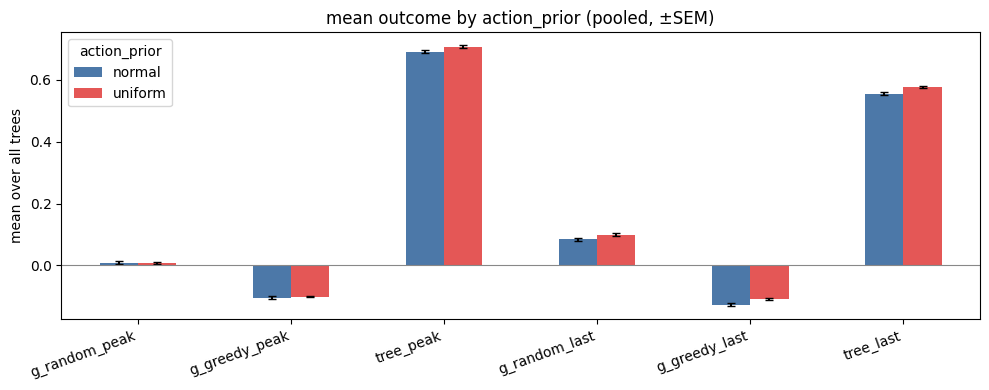

In [40]:
# both objectives on one bar chart; error bars are the SEM, so overlapping bars = no effect
m = df.groupby(PRIOR, observed=True)[OUTS].mean().T
e = df.groupby(PRIOR, observed=True)[OUTS].sem().T
ax = m.plot(kind="bar", yerr=e, figsize=(10, 4), capsize=3,
            color=[COL.get(c, None) for c in m.columns])
ax.axhline(0, color="#888", lw=0.8)
ax.set_ylabel("mean over all trees"); ax.set_title(f"mean outcome by {PRIOR} (pooled, ±SEM)")
plt.xticks(rotation=20, ha="right"); plt.tight_layout()

## 2. Knob response curves, overlaid by prior level

In [41]:
def overlay_response(factor, y=None, ax=None, data=None, by=None):
    """One OFAT response line per level of `by` on shared axes (charts.response is
    per-outcome; this is per-group). The zero line follows the same rule as charts.response:
    drawn for gains, where 0 is the matched baseline."""
    y = y or OUT
    d = data if data is not None else df
    by = by or PRIOR
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 3.4))
    for lvl, sub in d.groupby(by, observed=True):
        g = charts.ofat(sub, factor).groupby(factor, observed=True)[y]
        idx = g.mean().index
        numeric = pd.api.types.is_numeric_dtype(idx)
        x = idx.to_numpy(float) if numeric else list(range(len(idx)))
        ax.errorbar(x, g.mean().to_numpy(float), yerr=g.sem().to_numpy(float), marker="o",
                    capsize=3, ls=("-" if numeric else "none"), color=COL.get(lvl), label=lvl)
        if not numeric:
            ax.set_xticks(list(x), [str(v) for v in idx])
    if y.startswith(("g_", "delta_")):
        ax.axhline(0, color="#888", lw=0.8, ls="--")
    ax.set(xlabel=factor, ylabel=y, title=f"{y} vs {factor}")
    ax.legend(title="state and action priors", fontsize=8, frameon=False)
    return ax

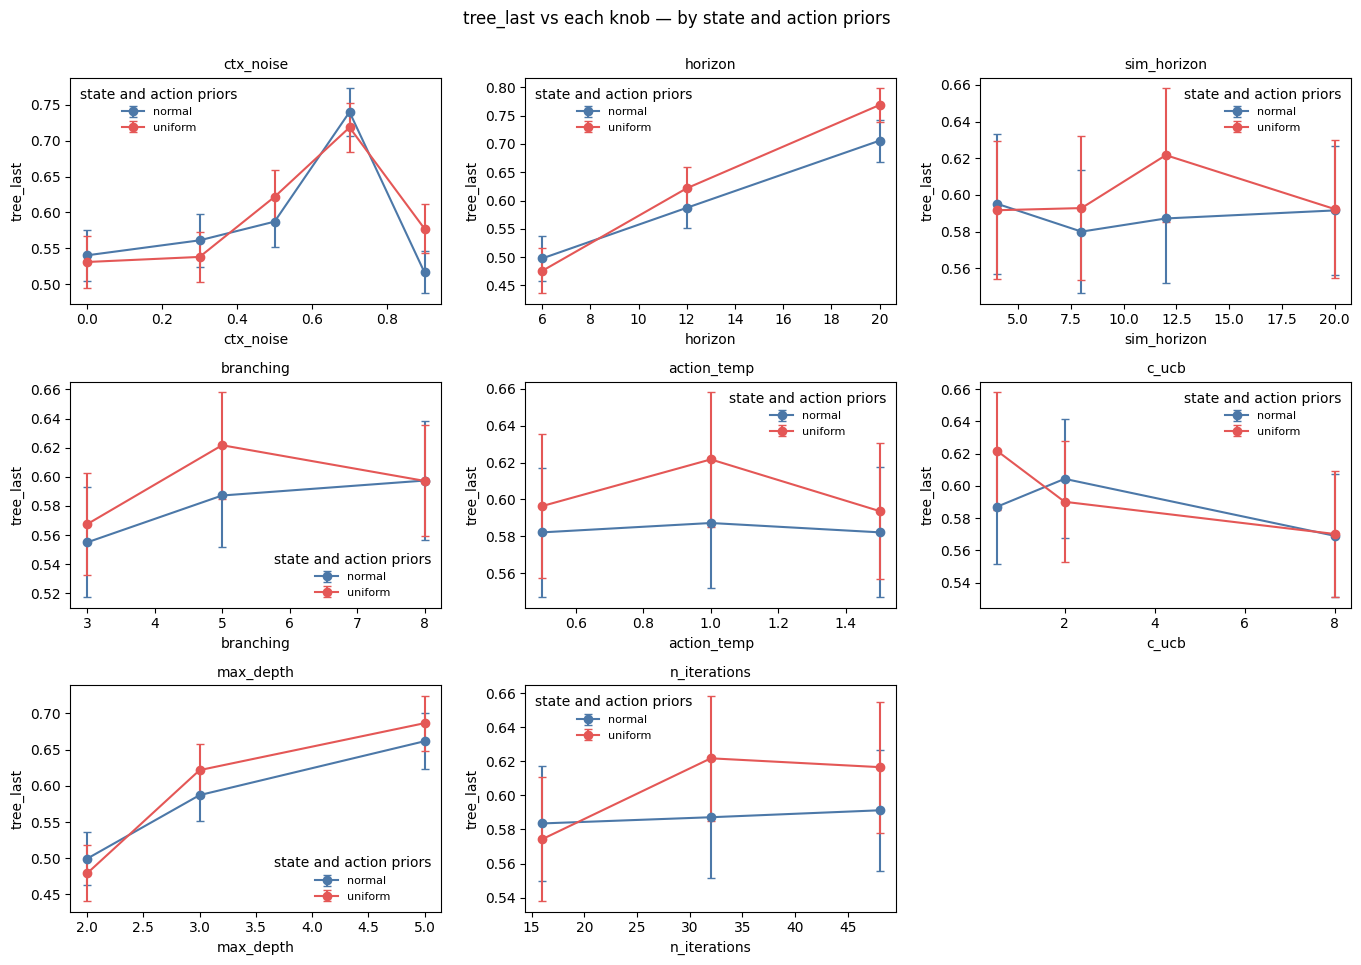

In [51]:
n = len(KNOBS); ncol = 3; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.6 * ncol, 3.2 * nrow), squeeze=False)
for ax, k in zip(axes.ravel(), KNOBS):
    overlay_response(k, ABS, ax=ax); ax.set_title(k, fontsize=10) #OUT
for ax in axes.ravel()[n:]:
    ax.axis("off")
fig.suptitle(f"{ABS} vs each knob — by state and action priors", y=1.0); fig.tight_layout() #OUT

### 2'. Where the prior should bite: `action_temp`

`action_temp` scales the prior and `action_prior` reshapes it, so if the shape matters
anywhere it should be where the sampler is stretched furthest. Shown on both objectives.

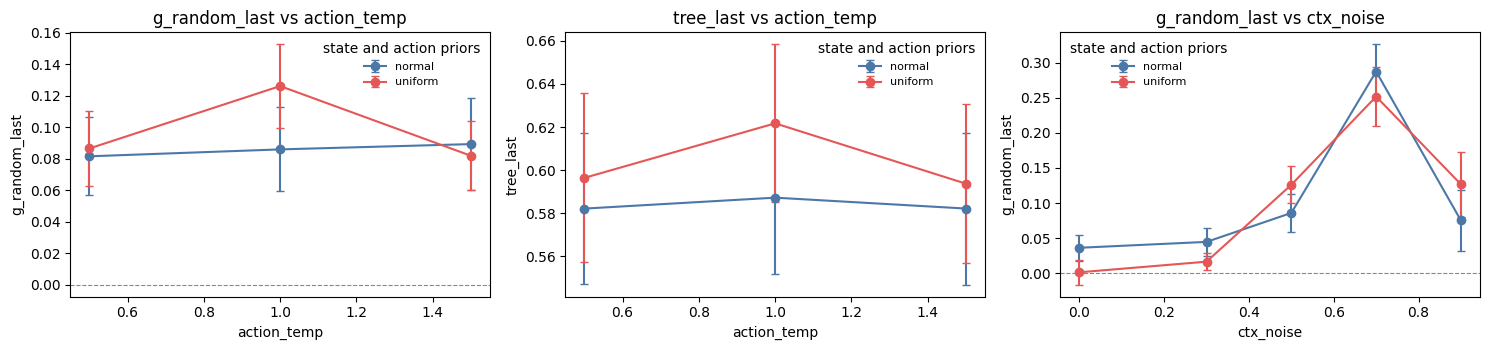

In [43]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
overlay_response("action_temp", GAIN,  ax=ax[0])
overlay_response("action_temp", ABS,   ax=ax[1])
overlay_response("ctx_noise",   GAIN,  ax=ax[2])
fig.tight_layout()

## 3. Outcome distributions, overlaid

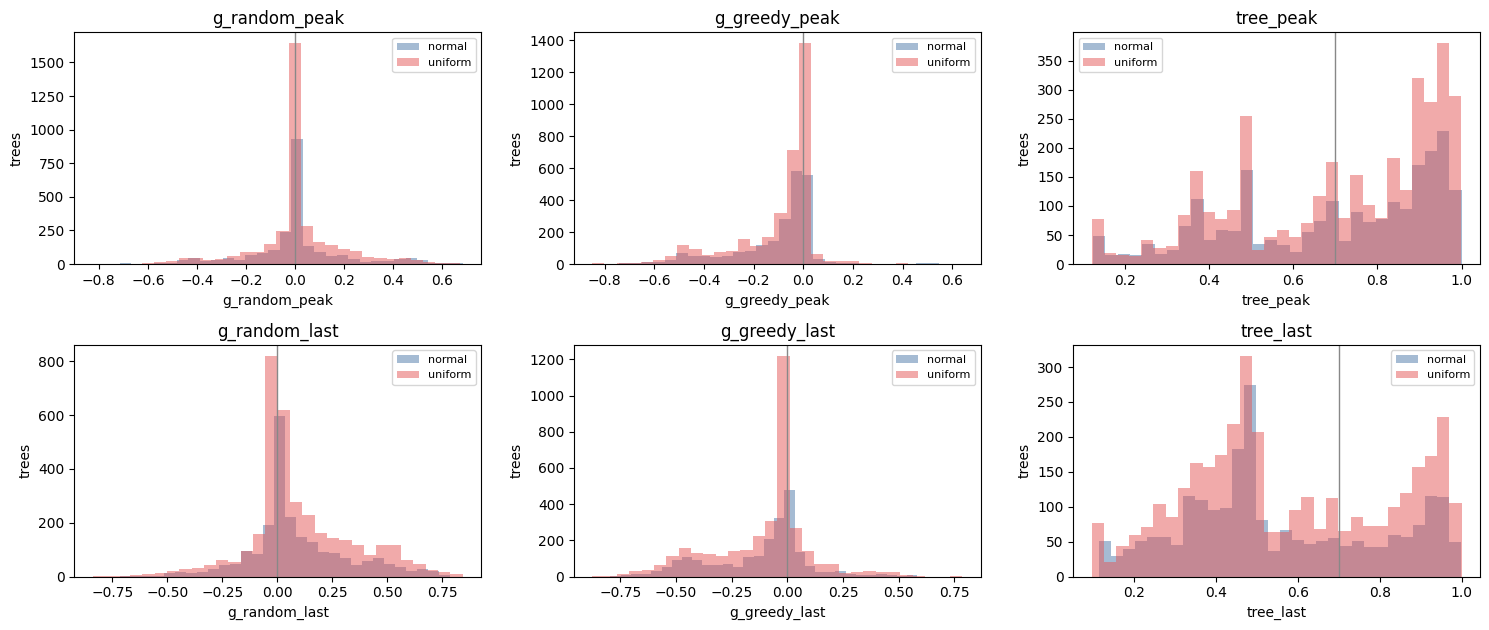

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6.4))
for a, c in zip(axes.ravel(), OUTS):
    for lvl, sub in df.groupby(PRIOR, observed=True):
        a.hist(sub[c].dropna(), bins=30, alpha=0.5, label=lvl, color=COL.get(lvl))
    a.axvline(0 if c.startswith("g_") else schema.PEAK_THRESHOLD, color="#888", lw=1)
    a.set(xlabel=c, ylabel="trees", title=c); a.legend(fontsize=8)
for a in axes.ravel()[len(OUTS):]:
    a.axis("off")
fig.tight_layout()

## 4. Does the prior change *what predicts* success?

Even a prior with no mean effect could change the mechanism. Compare the per-metric Spearman
ranking under each level: points on the diagonal = the same signals work either way.

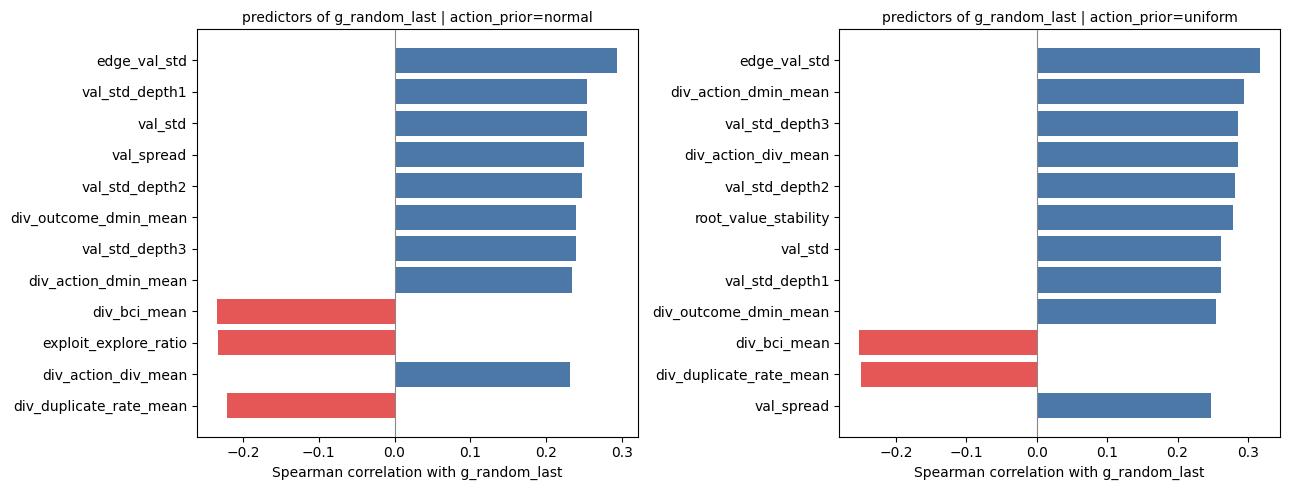

In [45]:
lv = sorted(df[PRIOR].dropna().unique())
fig, ax = plt.subplots(1, len(lv), figsize=(6.5 * len(lv), 5))
for a, l in zip(np.atleast_1d(ax), lv):
    charts.corr_bars(df[df[PRIOR] == l], OUT, top=12, ax=a)
    a.set_title(f"predictors of {OUT} | {PRIOR}={l}", fontsize=10)
fig.tight_layout()

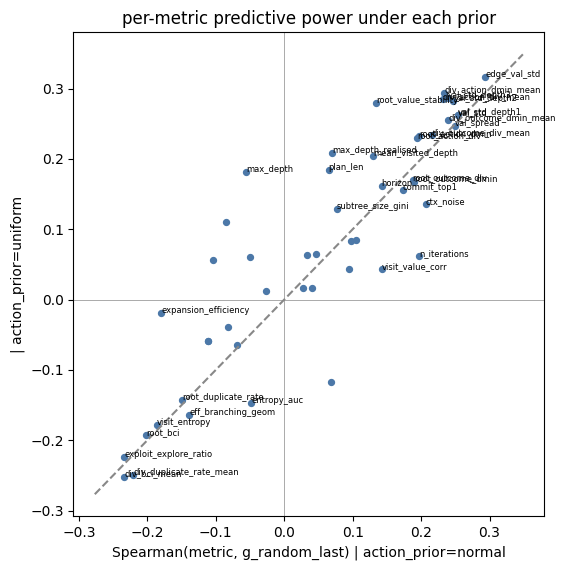

In [46]:
cs = [charts.correlations(df[df[PRIOR] == l], OUT).rename(l) for l in lv]
c = pd.concat(cs, axis=1).dropna()
fig, ax = plt.subplots(figsize=(5.8, 5.8))
ax.scatter(c[lv[0]], c[lv[1]], s=18, color="#4c78a8")
for mname, r in c.iterrows():
    if max(abs(r[lv[0]]), abs(r[lv[1]])) > 0.12:
        ax.annotate(mname, (r[lv[0]], r[lv[1]]), fontsize=6)
lim = [c.to_numpy().min() * 1.1, c.to_numpy().max() * 1.1]
ax.plot(lim, lim, "--", color="#888"); ax.axhline(0, color="#888", lw=.5); ax.axvline(0, color="#888", lw=.5)
ax.set(xlabel=f"Spearman(metric, {OUT}) | {PRIOR}={lv[0]}", ylabel=f"| {PRIOR}={lv[1]}",
       title="per-metric predictive power under each prior")
fig.tight_layout()

## 5. The controlled contrast — flip **only** the prior

The clean comparison, and it lives *inside* a run: hold every other knob and the init fixed,
and flip the prior. Each run's OFAT star supplies exactly one such arm (`base` vs
`ofat.<prior>=<other>`), so this is 40 paired trees per run — small, but genuinely controlled.

Pairing is on the **knob values**, never on `config_id` (see §0).

In [47]:
def controlled_flip(prior=PRIOR, data=None, lo="normal", hi="uniform"):
    """Pair trees that differ ONLY in `prior` (every other knob + init identical)."""
    d = df if data is None else data
    other = [k for k in schema.FACTORS if k in d.columns and k != prior]
    a = d[d[prior] == lo]
    b = d[d[prior] == hi]
    m = a.merge(b, on=other + ["init_id"], suffixes=("_lo", "_hi"))
    if not len(m):
        return None, m
    rows = []
    for o in OUTS:
        diff = m[f"{o}_hi"] - m[f"{o}_lo"]
        rows.append({"outcome": o, "n_pairs": len(m), "mean_diff": diff.mean(),
                     "sem": diff.sem(), "t": diff.mean() / (diff.sem() + 1e-12),
                     f"{hi}>{lo}_%": 100 * (diff > 0).mean()})
    return pd.DataFrame(rows).set_index("outcome"), m

for name, d in [("run_normal", dfs["normal"]), ("run_uniform", dfs["uniform"])]:
    tab, m = controlled_flip(data=d)
    print(f"--- {name}: flip {PRIOR} normal -> uniform, everything else fixed ---")
    print("no matched pairs" if tab is None else tab.round(4).to_string(), "\n")

--- run_normal: flip action_prior normal -> uniform, everything else fixed ---
               n_pairs  mean_diff     sem       t  uniform>normal_%
outcome                                                            
g_random_peak       40     0.0170  0.0127  1.3383              45.0
g_greedy_peak       40     0.0137  0.0108  1.2693              37.5
tree_peak           40     0.0122  0.0107  1.1441              42.5
g_random_last       40     0.0035  0.0072  0.4863              45.0
g_greedy_last       40    -0.0035  0.0091 -0.3902              37.5
tree_last           40     0.0024  0.0069  0.3449              40.0 

--- run_uniform: flip action_prior normal -> uniform, everything else fixed ---
               n_pairs  mean_diff     sem       t  uniform>normal_%
outcome                                                            
g_random_peak       40     0.0145  0.0105  1.3722              52.5
g_greedy_peak       40     0.0123  0.0103  1.1987              47.5
tree_peak           40 

In [48]:
tab, m = controlled_flip()          # pooled across runs
print(f"pooled: {len(m)} matched pairs")
tab.round(4)

pooled: 160 matched pairs


,n_pairs,mean_diff,sem,t,uniform>normal_%
outcome,,,,,
g_random_peak,160,0.0112,0.0084,1.3343,50.625
g_greedy_peak,160,0.0065,0.0082,0.7962,44.375
tree_peak,160,0.0062,0.0071,0.8837,48.125
g_random_last,160,0.0197,0.0094,2.0978,55.000
g_greedy_last,160,0.0135,0.0101,1.3346,47.500
tree_last,160,0.0099,0.0080,1.2309,50.625


## 6. The reproducibility floor — how much noise is there anyway?

Both runs contain trees with **identical knobs, identical init, and identical `plan_seed`**
(the Tier-2 `rand.*` configs are drawn from the same RNG seed in both runs, so they coincide).
Those pairs should be the *same tree twice*. Comparing them measures the run-to-run noise
floor — and it bounds every effect claimed above: a difference smaller than this cannot be
attributed to the prior.

In [49]:
KN = [k for k in schema.FACTORS if k in df.columns]
rep = dfs["normal"].merge(dfs["uniform"], on=KN + ["init_id", "plan_seed"], suffixes=("_a", "_b"))
print(f"{len(rep)} tree pairs with identical config + init + plan_seed across the two runs\n")

rows = []
for o in OUTS:
    d = rep[f"{o}_a"] - rep[f"{o}_b"]
    rows.append({"outcome": o, "mean_diff": d.mean(), "sd_of_diff": d.std(),
                 "abs_p50": d.abs().median(), "abs_p90": d.abs().quantile(0.90),
                 "sd_across_all_trees": df[o].std(),
                 # test-retest reliability: correlate the two supposedly-identical runs.
                 # 1 = perfectly reproducible, 0 = a re-run tells you nothing about the first.
                 "test_retest_r": rep[f"{o}_a"].corr(rep[f"{o}_b"])})
R = pd.DataFrame(rows).set_index("outcome")
# sd(a-b) = sd * sqrt(2(1-r)): 0 if reproducible, sqrt(2)~1.41 if the pair is independent
R["sd_ratio"] = R.sd_of_diff / R.sd_across_all_trees
R.round(4)

2080 tree pairs with identical config + init + plan_seed across the two runs



,mean_diff,sd_of_diff,abs_p50,abs_p90,sd_across_all_trees,test_retest_r,sd_ratio
outcome,,,,,,,
g_random_peak,0.0029,0.1573,0.0144,0.2904,0.1854,0.6774,0.8482
g_greedy_peak,0.0020,0.1633,0.0292,0.2993,0.1652,0.5449,0.9883
tree_peak,0.0024,0.1505,0.0121,0.2778,0.2408,0.8086,0.6248
g_random_last,0.0017,0.1935,0.0330,0.3666,0.2356,0.7005,0.8214
g_greedy_last,0.0045,0.2258,0.0631,0.4138,0.2245,0.5532,1.0057
tree_last,0.0008,0.1815,0.0257,0.3478,0.2424,0.7229,0.7486


If these two panels are not a tight diagonal / a spike at 0, the planner is NOT
reproducible at a fixed seed across processes, and any PER-TREE pairing is dominated
by that noise rather than by the treatment. Structural columns are a useful cross-check:
   n_nodes              identical in 67.8% of pairs
   n_forward            identical in 67.8% of pairs
   max_depth_realised   identical in 94.5% of pairs


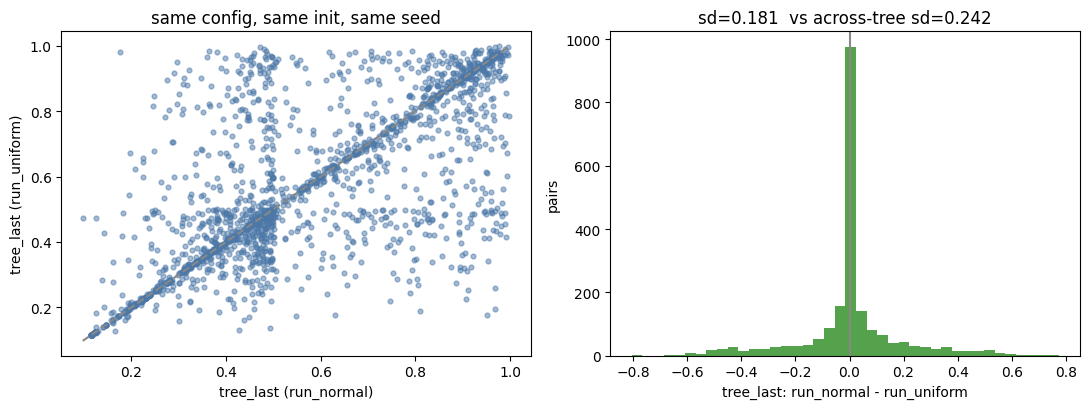

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].scatter(rep[f"{ABS}_a"], rep[f"{ABS}_b"], s=12, alpha=0.5, color="#4c78a8")
lim = [min(rep[f"{ABS}_a"].min(), rep[f"{ABS}_b"].min()), max(rep[f"{ABS}_a"].max(), rep[f"{ABS}_b"].max())]
ax[0].plot(lim, lim, "--", color="#888")
ax[0].set(xlabel=f"{ABS} (run_normal)", ylabel=f"{ABS} (run_uniform)",
          title="same config, same init, same seed")

d = rep[f"{ABS}_a"] - rep[f"{ABS}_b"]
ax[1].hist(d, bins=40, color="#54a24b")
ax[1].axvline(0, color="#888")
ax[1].set(xlabel=f"{ABS}: run_normal - run_uniform", ylabel="pairs",
          title=f"sd={d.std():.3f}  vs across-tree sd={df[ABS].std():.3f}")
fig.tight_layout()

print("If these two panels are not a tight diagonal / a spike at 0, the planner is NOT")
print("reproducible at a fixed seed across processes, and any PER-TREE pairing is dominated")
print("by that noise rather than by the treatment. Structural columns are a useful cross-check:")
for c in ["n_nodes", "n_forward", "max_depth_realised"]:
    if f"{c}_a" in rep.columns:
        print(f"   {c:20s} identical in {(rep[f'{c}_a'] == rep[f'{c}_b']).mean():.1%} of pairs")

### Reading §6

`test_retest_r` is the headline: the correlation between the *same tree computed twice*.
1 means the planner is reproducible and a matched pair removes all noise; 0 means a re-run
tells you nothing about the first. `sd_ratio` says the same thing on the spread scale — it
is `sqrt(2(1-r))`, so 0 = reproducible and ~1.41 = the two runs are independent draws.

If the floor is large, the honest conclusions are:

1. **Trust the marginal comparisons (§1–§4), not the per-tree ones.** With thousands of
   trees per level the mean is still well estimated; a single matched pair is not.
2. **§5's 40-pair contrasts carry a standard error of the same order as the effect** —
   report them as bounds ("no effect larger than X detectable"), not as measurements.
3. **Worth isolating the cause before drawing conclusions from any seed-matched design.**
   The likely candidate is nondeterministic CUDA reductions in bf16, amplified by MCTS's
   argmax selection (one flipped comparison early diverges the whole tree) — but that is a
   hypothesis. The direct test is cheap: build the same tree twice **in one process** with
   the same seed and diff the trace. If it reproduces there but not across runs, something
   in the run setup differs; if it does not reproduce even there, it is kernel-level
   nondeterminism and `n_seeds` replicates are measuring that as much as seed variance.

### Notes
- Every chart splits by the **column** `PRIOR` (`action_prior` by default — set it to
  `state_prior` at the top and re-run), coloured blue=normal / red=uniform.
- `run` is provenance, not the treatment: the two bases differ in *both* priors at once.
- Flip `OBJ` between `"peak"` and `"last"` in the setup to re-run everything on the other
  objective; §1, §3 and §6 always show both.